<a href="https://colab.research.google.com/github/ranvirdkr/CSCI-A-310/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
hour=pd.read_csv('hour.csv')

In [3]:
print(hour.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  count  
0           1  0.24  0.2879  0.81        0.0       3          13     16  
1           1  0.22  0.2727  0.80        0.0       8          32     40  
2           1  0.22  0.2727  0.80        0.0       5          27     32  
3           1  0.24  0.2879  0.75        0.0       3          10     13  
4           1  0.24  0.2879  0.75        0.0       0           1      1  


In [4]:
print(hour['count'].mean())

189.46308763450142


In [5]:
print(hour['count'].median())
print(hour['count'].std())
print(hour['registered'].min())
print(hour['registered'].max())

142.0
181.38759909186527
0
886


In [6]:
print(hour.describe())

          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000   
max    17379.0000      4.000000      1.000000     12.000000     23.000000   

            holiday       weekday    workingday    weathersit          temp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.028770      3.003683      0.682721      1.425283      0.496987   
std        0.167165      2.005771      0.465431      0.639357      0.

With these 4 print statements the outputs were the first 5 rows of the data, calculating the mean of the count column, calulating the median/standard deviation of count and the min/max of registered, and the summary statistics of all the variables.

In [7]:
print(hour.loc[3,'count'])

13


In [9]:
print(hour.loc[2:4,'registered'])

2    27
3    10
4     1
Name: registered, dtype: int64


In [11]:
print(hour.loc[hour['hr']<5,'registered'].mean())

20.7881427367238


In [12]:
print(hour.loc[(hour['hr']<5) & (hour['temp']<.50),'count'].mean())
print(hour.loc[(hour['hr']<5) & (hour['temp']>.50),'count'].mean())

19.521104742053154
33.639322916666664


We analyzed the nightime data in our print statements and getting the outputs from the 3rd row of the count column, getting values from rows 2 to 4 of registered, checking if the hr is less than 5 we will get the mean of the registered column, using to conditions that the hr < 5 and temp< and >.50 using the count column

In [14]:
print(hour.groupby(['season'])['count'].mean())

season
1    111.114569
2    208.344069
3    236.016237
4    198.868856
Name: count, dtype: float64


In [15]:
print(hour.groupby(['season','holiday'])['count'].mean())

season  holiday
1       0          112.685875
        1           72.042683
2       0          208.428472
        1          204.552083
3       0          235.976818
        1          237.822917
4       0          199.965998
        1          167.722222
Name: count, dtype: float64


We analyzed the seasonal data in our print statements and getting the outputs from using a groupby and getting the 4 seasons and the mean count value of each, groupby for both season and holidy columns and print mean of counts.

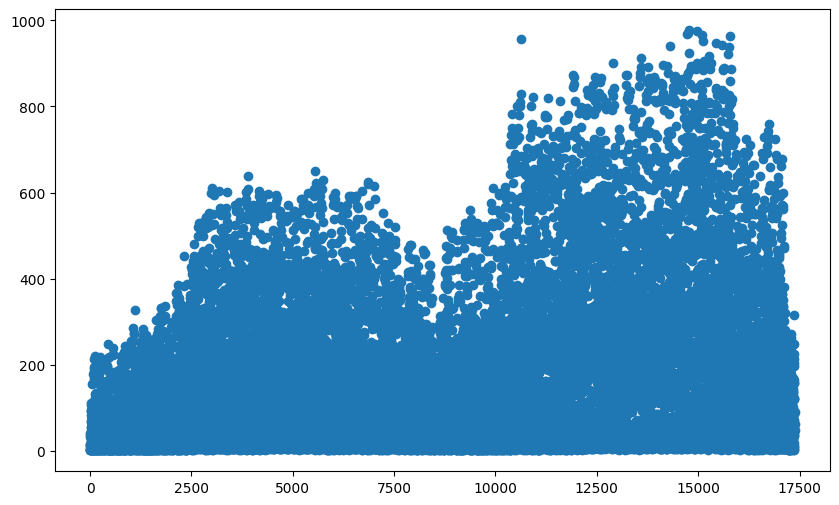

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = hour['instant'], y = hour['count'])
plt.show()

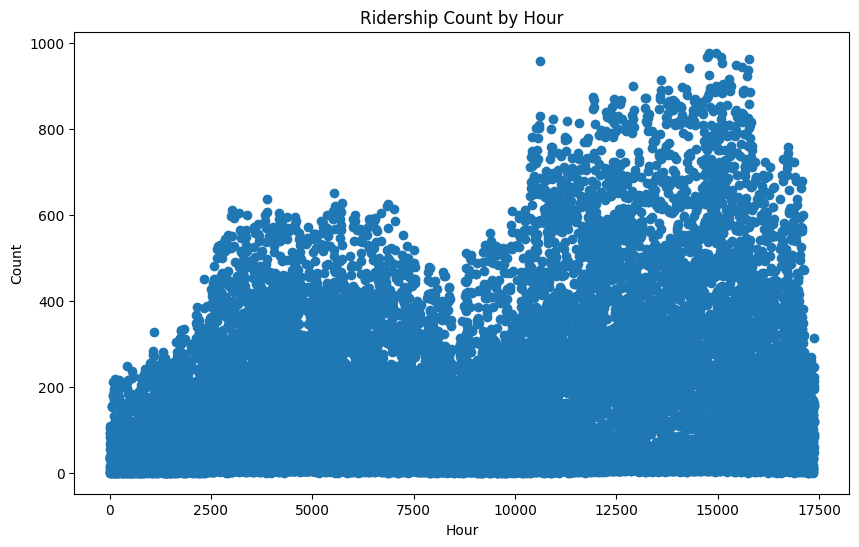

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = hour['instant'], y = hour['count'])
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Ridership Count by Hour")
plt.show()

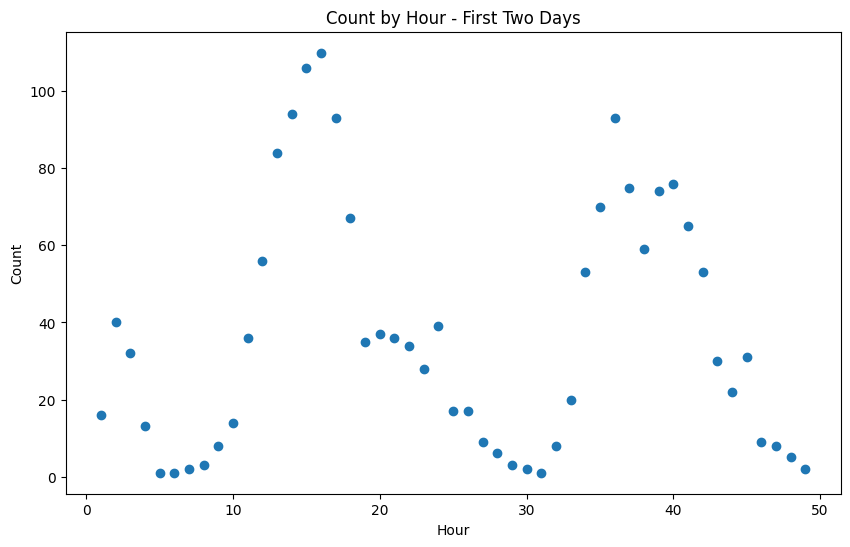

In [19]:
hour_first48=hour.loc[0:48,:]
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = hour_first48['instant'], y = hour_first48['count'])
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Count by Hour - First Two Days")
plt.show()

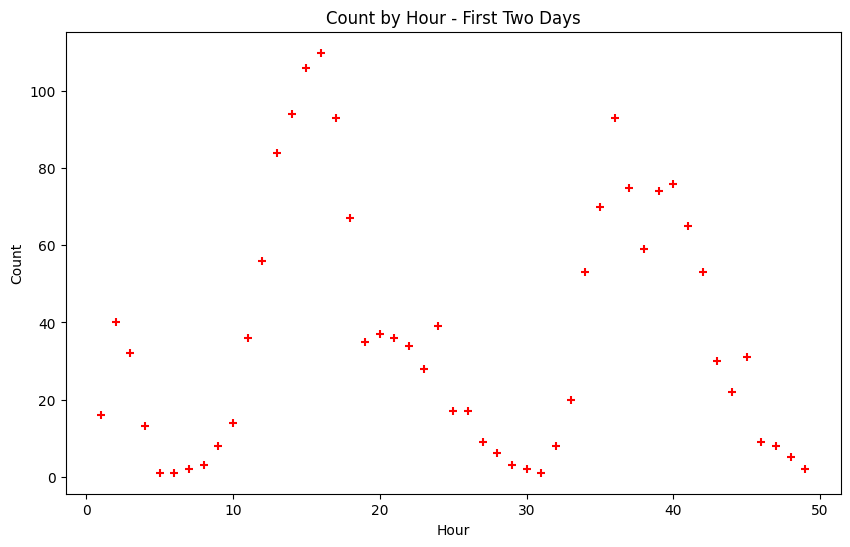

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = hour_first48['instant'], y = hour_first48['count'],c='red',marker='+')
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Count by Hour - First Two Days")
plt.show()

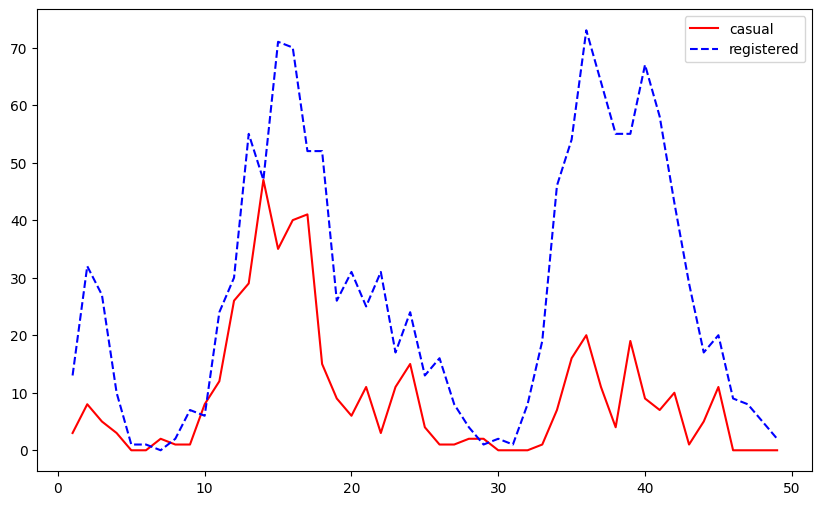

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(hour_first48['instant'], hour_first48['casual'],c='red',label='casual',linestyle='-')
ax.plot(hour_first48['instant'],\
hour_first48['registered'],c='blue',label='registered',linestyle='--')
ax.legend()
plt.show()

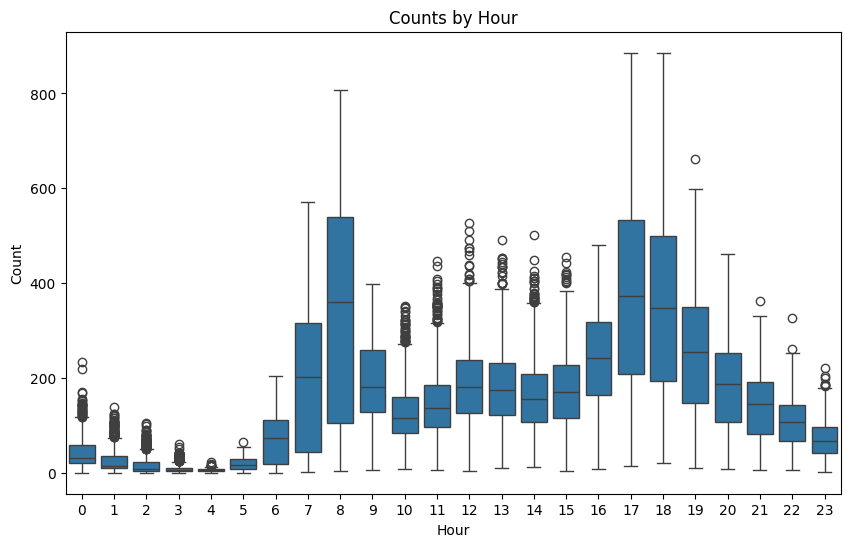

In [21]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='hr', y='registered', data=hour)
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Counts by Hour")
plt.show()

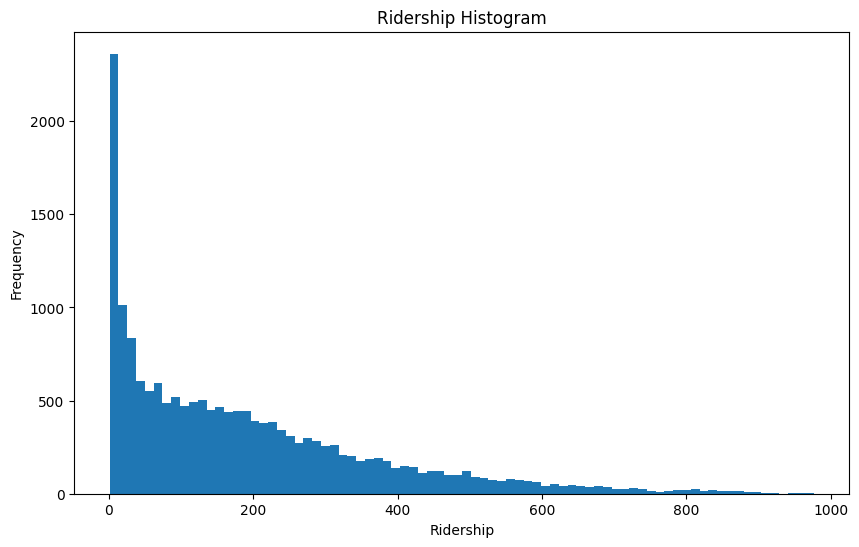

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(hour['count'],bins=80)
plt.xlabel("Ridership")
plt.ylabel("Frequency")
plt.title("Ridership Histogram")
plt.show()

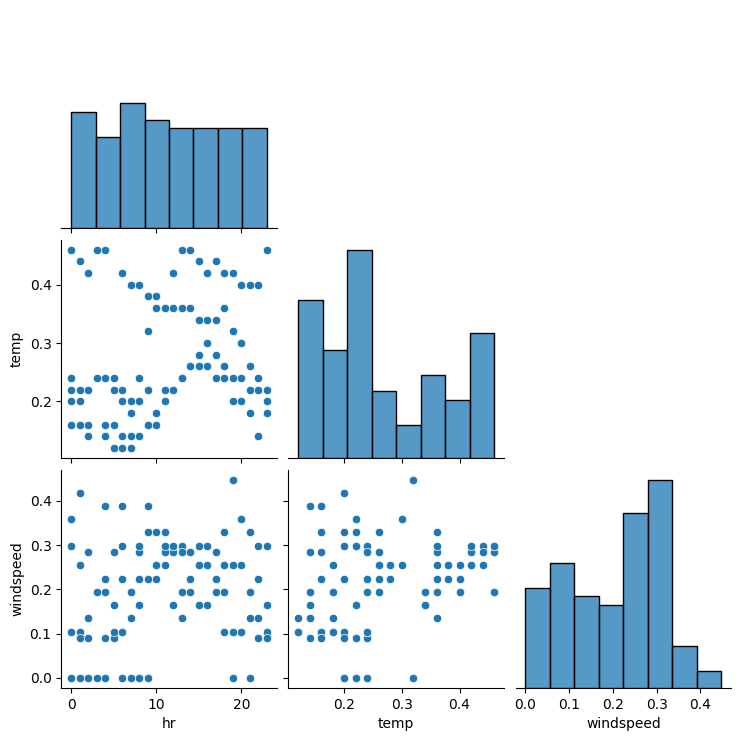

In [25]:
thevariables=['hr','temp','windspeed']
hour_first100=hour.loc[0:100,thevariables]
sns.pairplot(hour_first100, corner=True)
plt.show()

For all the plots we are using matplotlib to visualize the data. In the first plot we did a scatter and we are having the x intercept as instant and the y intercept as count. For the second plot we did not change much but the labels to the x and y intercepts and adding a title. For the third plot we are plotting subsets for instant and count, adding labels, and a title. For the fourth plot we changed the marker style to a + and the color to red. For the fifth plot we  did 2 line plots with dashed lines and the other with straight line. For the sixth plot we used seaborn to make a box plot. For the we used matplotlib to visualize a histogram. For the 7th plot we used to make 3 scatter plots and 3 bar graphs.

In [29]:
print(hour['casual'].corr(hour['registered']))
print(hour['temp'].corr(hour['hum']))

0.5066177004294634
-0.06988139105119354


In [27]:
thenames=['hr','temp','windspeed']
cor_matrix = hour[thenames].corr()
print(cor_matrix)

                 hr      temp  windspeed
hr         1.000000  0.137603   0.137252
temp       0.137603  1.000000  -0.023125
windspeed  0.137252 -0.023125   1.000000


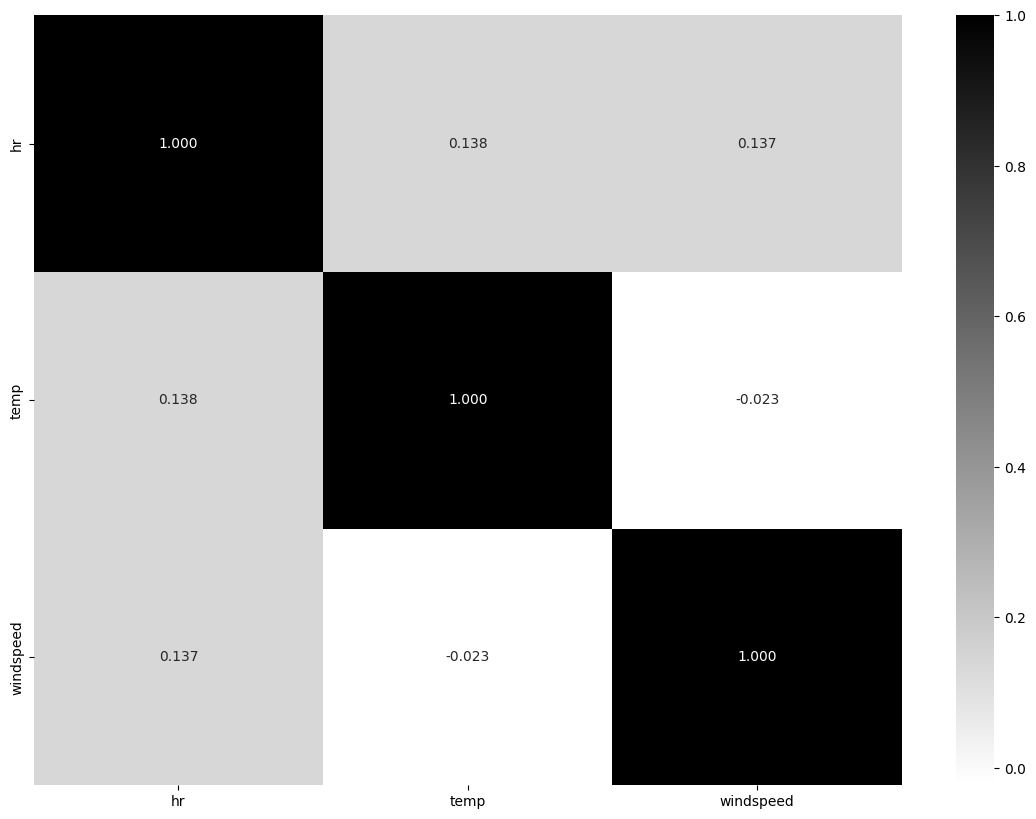

In [30]:
plt.figure(figsize=(14,10))
corr = hour[thenames].corr()
sns.heatmap(corr, annot=True,cmap='binary',
 fmt=".3f",
 xticklabels=thenames,
 yticklabels=thenames)
plt.show()

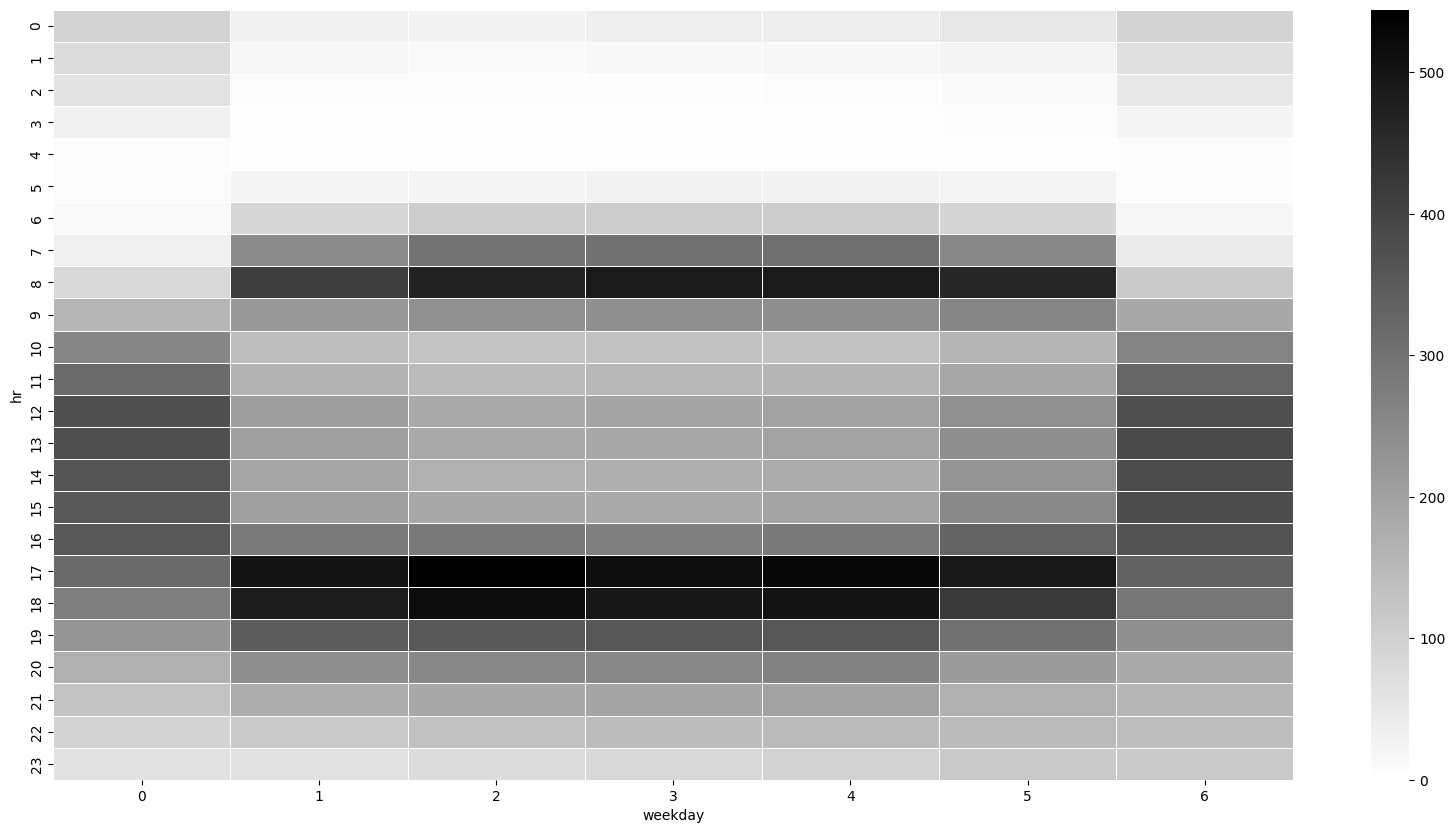

In [28]:
# Create a pivot table
df_hm =hour.pivot_table(index = 'hr',columns ='weekday',values ='count')
# Draw a heatmap
plt.figure(figsize = (20,10)) # To resize the plot
sns.heatmap(df_hm, fmt="d", cmap='binary',linewidths=.5, vmin = 0)
plt.show()

To explain the heatmap the different shades mean different things. It shows that if 2 attributes are highly correlated or negativley correlated they show up darker and are grey and lighter as they are less.

I enjoyed the different plots I learned to make and the process of importing different things to make them. As well as learning how to specify the different parts that I need from a big data set and getting the different calculations from them. I like how you can take things from a specific row and choose certain parts from the row to perform any calculation.